In [1]:
import numpy as np
import scipy.optimize as opt
import scipy.interpolate as si
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import time
import numpy.matlib
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import warnings
from typing import Optional, Union
from abc import ABC, abstractmethod

warnings.filterwarnings('ignore')

# Demography

## Opening data

In [ ]:
pop = pd.read_excel('/home/cocochamba/Desktop/pop/total_pop.xlsx') # in thousands
pop.set_index('Year', inplace=True)
pop /= 1000 # now in mils
pop.head()

In [ ]:
def get_mort(totpers, graph=False):
    data = pd.read_excel('/home/cocochamba/Desktop/pop/death_probability.xlsx')
    data.set_index('Year', inplace=True)
    mort = pd.DataFrame(index=data.index, columns=np.arange(totpers)+1)
    for i, year in enumerate(data.index):
        mort_data = data.iloc[i, :]
        mort_data.loc[-1] = 0
        mort_data.loc[-2] = 0
        mort_data.loc[101] = 1
        mort_data.loc[102] = 1
        
        age_midp = mort_data.index.values
      
        fit_mort = si.interp1d(age_midp, mort_data, kind='cubic', bounds_error=False, fill_value=0)
        
        age_model = np.linspace(100 / totpers, 100, totpers) - (0.5 * 100 / totpers)
        mort_model = fit_mort(age_model)
        fit = fit_mort(np.linspace(0, 100, 1000))

        mort.loc[year] = mort_model
    return mort

In [ ]:
mort = get_mort(100)
mort.head()

In [ ]:
migr = pd.read_excel('/home/eurapartners.local/moiseev.kv/Repositories/Cost_of_ageing/Data/age specific migration.xlsx',
                     sheet_name='age migration') # in thousands
migr.set_index('Year', inplace=True)
migr /= 1000 # now in mils
migr.head()

## Plotting

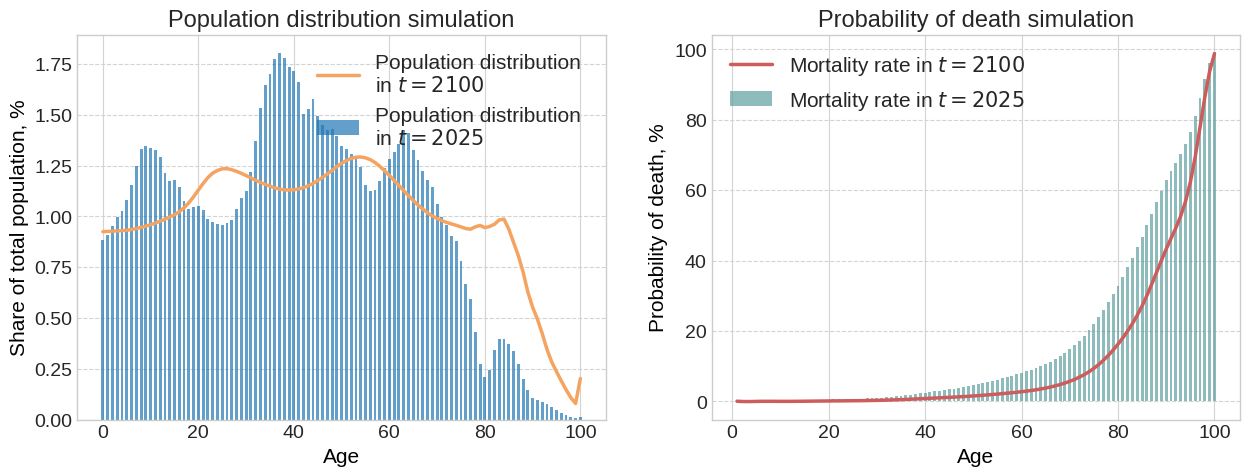

In [49]:
fig, ax = plt.subplots(1, 2, figsize=[15, 5])

ax[0].bar(pop.columns, 100 * pop.iloc[0, :] / pop.iloc[0, :].sum(), width=.6, 
        alpha=.7, label = 'Population distribution \nin $t=2025$', color='C0')
ax[0].plot(pop.columns, 100 * pop.iloc[-1, :] / pop.iloc[-1, :].sum(), linewidth=2.5, 
        label = 'Population distribution \nin $t=2100$', color='sandybrown')

ax[0].set_xlabel('Age', fontsize = 15, color='black')
ax[0].set_ylabel(r'Share of total population, %', fontsize = 15, color='black')
ax[0].grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax[0].grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax[0].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)

ax[0].legend(fontsize=15)
ax[0].set_title('Population distribution simulation', fontsize=17)

ax[1].bar(mort.columns, 100 * mort.iloc[0, :], width=.6, 
        alpha=.7, label = r'Mortality rate in $t=2025$', color='cadetblue')
ax[1].plot(mort.columns, 100 * mort.iloc[-1, :], linewidth=2.5, 
        label = r'Mortality rate in $t=2100$', color='indianred')

ax[1].set_xlabel('Age', fontsize = 15, color='black')
ax[1].set_ylabel(r'Probability of death, %', fontsize = 15, color='black')
ax[1].grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax[1].grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)

ax[1].legend(fontsize=15)
ax[1].set_title('Probability of death simulation', fontsize=17)

plt.savefig('popdistr.svg', dpi=300)

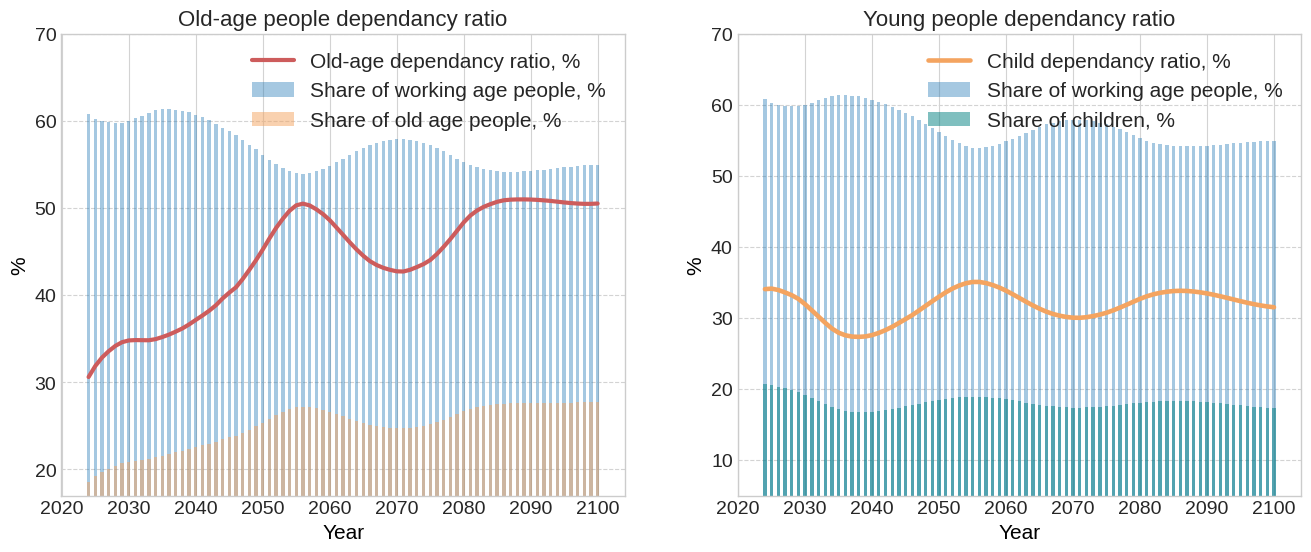

In [50]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(pop.index, 100 * (pop.iloc[:, 64:].sum(axis=1) / pop.iloc[:, 18:64].sum(axis=1)), 
        label = r'Old-age dependancy ratio, %', color='indianred', linewidth=3, alpha=1,)
ax1.bar(pop.index, 100 * pop.iloc[:, 18:64].sum(axis=1) / pop.sum(axis=1),
        label = r'Share of working age people, %', color='C0', width=0.5, alpha=.4)
ax1.bar(pop.index, 100 * pop.iloc[:, 64:].sum(axis=1) / pop.sum(axis=1),
        label = r'Share of old age people, %', color='sandybrown', width=0.5, alpha=.5)

ax1.set_xlabel('Year', fontsize = 15, color='black')
ax1.set_ylabel(r'%', fontsize = 15, color='black')
ax1.grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax1.grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

ax1.set_ylim([17, 70])

ax1.legend(fontsize=15)
ax1.set_title('Old-age people dependancy ratio', fontsize=16)


ax2.plot(pop.index, 100 * (pop.iloc[:, :18].sum(axis=1) / pop.iloc[:, 18:64].sum(axis=1)), 
        label = r'Child dependancy ratio, %', color='sandybrown', linewidth=3.3, alpha=1,)
ax2.bar(pop.index, 100 * pop.iloc[:, 18:64].sum(axis=1) / pop.sum(axis=1),
        label = r'Share of working age people, %', color='C0', width=0.5, alpha=.4)
ax2.bar(pop.index, 100 * pop.iloc[:, :18].sum(axis=1) / pop.sum(axis=1),
        label = r'Share of children, %', color='teal', width=0.5, alpha=.5)

ax2.set_xlabel('Year', fontsize = 15, color='black')
ax2.set_ylabel(r'%', fontsize = 15, color='black')
ax2.grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax2.grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax2.set_ylim([5, 70])

ax2.legend(fontsize=15)
ax2.set_title('Young people dependancy ratio', fontsize=16)

plt.savefig('ratio.png', dpi=300)

# Production

## Cobb-Doughlas

In [10]:
data = pd.read_excel('/home/cocochamba/Desktop/pop/for_prod_function.xlsx', sheet_name='real')
data.set_index('Год', inplace=True)

data.head()

,ВНОК,ВВП,Занятых
Год,,,
1999,13.327365,47.205865,72.791
2000,21.512807,59.495500,72.332
2001,19.979310,61.422225,71.411
2002,18.673836,64.645690,72.421
2003,19.912721,70.397164,72.835


In [11]:
logdata = np.log(data)
logdata = logdata.diff().dropna()
y = logdata['ВВП']
x = sm.add_constant(logdata[['ВНОК', "Занятых"]])

GLM = sm.GLM(y, x)
result = GLM.fit_constrained(([0, 1, 1], 1))

In [12]:
alpha = result.params[1]
g_y = result.params[0] / result.params[2]

In [13]:
y_ln = np.log(data['ВВП'])
k_ln = np.log(data['ВНОК'])
l_ln = np.log(data['Занятых'])
t = np.arange(data.shape[0]) + 1

y = np.exp(
    y_ln - alpha * k_ln - (1-alpha) * (l_ln + t * g_y)
)

A = np.mean(y)

In [14]:
print('Alpha =', alpha, 'g_y =', g_y, 'A =', A)

Alpha = 0.38985885478080146 g_y = 0.054119983288034655 A = 1.4031195917181967


In [15]:
Y_model = A * data['ВНОК'] ** (alpha) * (np.exp(g_y * t) * data['Занятых']) ** (1 - alpha)

In [16]:
r_real = pd.read_excel('/home/cocochamba/Desktop/pop/keyrate.xlsx')
r_real['year'] = pd.to_datetime(r_real['year'], format='%Y-%m-%d')
r_real.set_index('year', inplace=True)
r_real.tail()

,rate
year,
2020-01-01,4.94000
2021-01-01,5.98000
2022-01-01,11.00000
2023-01-01,9.12808
2024-01-01,15.85200


In [17]:
delta = 0.05
r_model = alpha * A * (np.exp(g_y*t) * data.iloc[:, 2] / (data.iloc[:, 0]*30)) ** (1 - alpha) - delta

In [18]:
wage = pd.read_excel('/home/cocochamba/Desktop/pop/for_prod_function.xlsx', sheet_name='wage')

In [19]:
wage_model = (1 - alpha) * (data.iloc[:, 1] / data.iloc[:, 2])
model = sm.OLS(wage, wage_model.values).fit()
scaling = model.params[0]
wage_model *= scaling

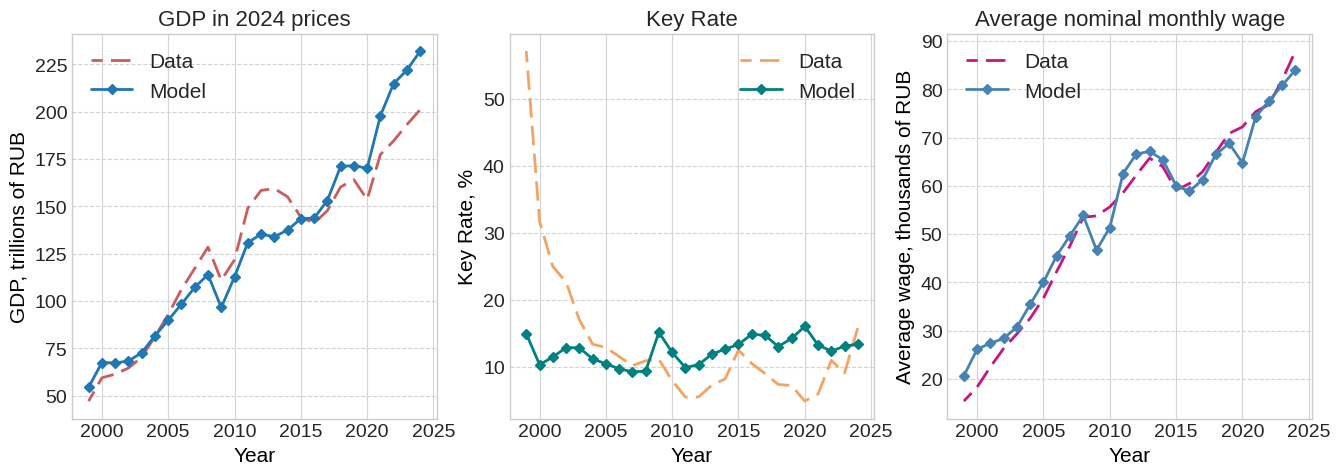

In [51]:
fig, ax = plt.subplots(1, 3, figsize=[16, 5])

ax[0].plot(data.index, data['ВВП'], label='Data', c='indianred', linewidth=2, linestyle=(3, (7, 3)))
ax[0].plot(data.index, Y_model, label='Model', marker='D', linestyle='-', c = 'C0', linewidth=2, markersize=5)

ax[0].set_xlabel('Year', fontsize = 15, color='black')
ax[0].set_ylabel(r'GDP, trillions of RUB', fontsize = 15, color='black')
ax[0].grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax[0].grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax[0].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)

ax[0].legend(fontsize=15)
ax[0].set_title('GDP in 2024 prices', fontsize=16)


ax[1].plot(data.index, r_real, label='Data', c='sandybrown', linewidth=2, linestyle=(3, (7, 3)))
ax[1].plot(data.index, r_model * 100, label='Model', marker='D', linestyle='-', c = 'teal', linewidth=2, markersize=5)

ax[1].set_xlabel('Year', fontsize = 15, color='black')
ax[1].set_ylabel(r'Key Rate, %', fontsize = 15, color='black')
ax[1].grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax[1].grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)


ax[1].legend(fontsize=15)
ax[1].set_title('Key Rate', fontsize=16)


ax[2].plot(wage_model.index, wage / 1000, label='Data', c='mediumvioletred', linewidth=2, linestyle=(3, (7, 3)))
ax[2].plot(wage_model / 1000, label='Model', marker='D', linestyle='-', c = 'steelblue', linewidth=2, markersize=5)

ax[2].set_xlabel('Year', fontsize = 15, color='black')
ax[2].set_ylabel(r'Average wage, thousands of RUB', fontsize = 15, color='black')
ax[2].grid(axis ='x', which='major', linestyle='-', color='lightgrey')
ax[2].grid(axis ='y', which='major', linestyle='--', color='lightgrey')
ax[2].tick_params(axis='x', labelsize=14)
ax[2].tick_params(axis='y', labelsize=14)


ax[2].legend(fontsize=15)
ax[2].set_title('Average nominal monthly wage', fontsize=16)

plt.savefig('cobb-douglas.png', dpi=300)

## Ammortization rate

Ammortization rate coefficient $\delta = 0.05$ is chosen, as in:

https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2168632

## Frisch labor elasticity and elleptic elasticity

In [21]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [52]:
def get_sumsq(ellip_params, *args):
    b, upsilon = ellip_params
    elast_Frisch, nvec, ltilde = args
    
    mu_cfe = nvec ** (1 / elast_Frisch)
    
    mu_ellip = ((b / ltilde) * ((nvec / ltilde) ** (upsilon - 1)) * ((1 - ((nvec / ltilde) ** upsilon)) ** \
               ((1 - upsilon) / upsilon)))
    
    sumsq = ((mu_cfe - mu_ellip) ** 2).sum()

    return sumsq

def fit_ellip(ellip_init, elast_Frisch, ltilde, graph = False):
    nvec = np.linspace(0.05, 0.95, 1000)
    args = (elast_Frisch, nvec, ltilde)
    bnds_elp = ((1e-12, None), (1 + 1e-12, None))
    
    ellip_params = opt.minimize(
        get_sumsq, ellip_init, args=(args), method='L-BFGS-B',
        bounds = bnds_elp)
    
    if ellip_params.success:
        b_ellip, upsilon = ellip_params.x
    else:
        raise ValueError("Failed to minimize sum of squares")
    if graph:
        MU_ellip = \
            ((b_ellip / ltilde) * ((nvec / ltilde) ** (upsilon - 1)) *
             ((1 - ((nvec / ltilde) ** upsilon)) ** ((1 - upsilon) / upsilon)))
        
        MU_CFE = nvec ** (1 / elast_Frisch)
        
        fig, ax = plt.subplots(figsize=[10, 4])
        #plt.style.use('seaborn-whitegrid')
        plt.plot(nvec, MU_ellip, label=r'Elleptic ($b$' + f' = {"{0:.3f}".format(b_ellip)}; ' + \
                 r'${\upsilon}$' + f' = {"{0:.3f}".format(upsilon)})', linestyle='-', c = 'indianred', linewidth=3.5)
        plt.plot(nvec, MU_CFE, label=r'CFE (${\theta} = $'+f'{"{0:.3f}".format(elast_Frisch)})', 
                 linestyle=(4, (7, 2.5)), c = 'C0', linewidth=3.5)
        # for the minor ticks, use no labels; default NullFormatter
        minorLocator = MultipleLocator(1)
        ax.xaxis.set_minor_locator(minorLocator)
        #plt.title('Предельная полезность труда Фриша и эллиптическая', fontsize=20)
        plt.grid(axis ='x', which='major', linestyle='-')
        plt.grid(axis ='y', which='major', linestyle='--')
        plt.xlabel(r'Labour supply $n_{s,t}$', fontsize = 15)
        plt.ylabel(r'Marginal utility', fontsize = 15)
        plt.xlim((0, ltilde))
        plt.tick_params(axis='x', labelsize=14)
        plt.tick_params(axis='y', labelsize=14)
        plt.legend(loc='upper left', fontsize = 15)
        
        plt.savefig('ellip.png')
        return b_ellip, upsilon

(np.float64(0.43090770734894246), np.float64(1.7647977407822446))

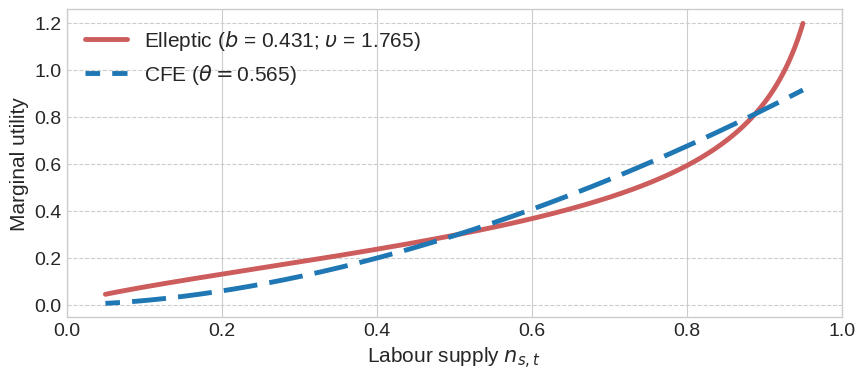

In [53]:
elast_Frisch = 1/1.77
ltilde = 1

fit_ellip((1, 1), elast_Frisch, ltilde, graph = True)

So, $b = 0.43; {\upsilon} = 1.765$

## Intertemporal elasticity of substitution

The value of Intertemporal elasticity of substitution is chosen to be $\sigma = 1.97$ following:

https://www.tandfonline.com/doi/abs/10.1080/10168737.2018.1561738

and

https://www.researchgate.net/profile/Valery-Charnavoki-2/publication/266412744_International_Risk-Sharing_and_Optimal_Monetary_Policy_in_a_Small_Commodity-Exporting_Economy/links/58f5f55d458515ff23b65dd0/International-Risk-Sharing-and-Optimal-Monetary-Policy-in-a-Small-Commodity-Exporting-Economy.pdf

## Subjective discounting factor

The value for Subjective discounting factor is chosen to be$\beta = 0.905$, as in:

https://publications.hse.ru/pubs/share/folder/23pebr3ex8/112751408.pdf

# Model

## Steady State

In [4]:
class AggregateEconomy:
    def __init__(
            self, 
            A: float, 
            alpha: float,
            omega: Optional[np.array] = None, 
            stationary: Optional[bool] = False, 
            imigr: Optional[np.array] = None,
            g_y: Optional[float] = None, 
            delta: Optional[float] = 0, 
            tau_c: Optional[float] = None,
    ):
        self.omega = omega
        self.stationary = stationary
        self.imigr = imigr
        self.g_y = g_y
        self.A = A
        self.alpha = alpha
        self.delta = delta
        self.tau_c = tau_c

    def get_L(self, narr: np.array):
        assert narr.ndim == self.omega.ndim, f'narr (dim f{narr.ndim}) and omega (dim f{self.omega.ndim}) need to be of the same dim'
        
        L = (narr * self.omega).sum(axis=0)
        
        if self.stationary:
            L /= self.omega.sum(axis=0)
        return L

    def get_K(self, barr: np.array):
        assert barr.ndim == self.omega.ndim == self.imigr.ndim, f'barr (dim {barr.ndim}), imigr (dim {self.omega.ndim}) and omega (dim {self.imigr.ndim}) need to be of the same dim'
        if self.stationary: assert isinstance(self.g_y, float), f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'
        
        K = (self.omega[:-1] * barr[1:]).sum(axis=0) + (self.imigr * self.omega * barr)[1:].sum(axis=0)
        
        if self.stationary:
            t = np.arange(len(K)) + 1 if len(K) > 1 else 1
            K /= np.exp(t * self.g_y) * self.omega.sum(axis=0)
        return K

    def get_Y(self, K: np.array, L: np.array):
        if self.stationary: assert isinstance(self.omega, np.ndarray), f'omega needs to be np.array for stationarization, {type(self.omega)} was given instead'
        
        t = np.arange(len(K)) + 1 if len(K) > 1 else 1
        Y = self.A * (K ** self.alpha) * ((np.exp(t * self.g_y) * L) ** (1 - self.alpha))
        
        if self.stationary:
            Y /= np.exp(t * self.g_y) * self.omega.sum(axis=0)
        return Y

    def get_C(self, carr: np.array):
        assert carr.ndim == self.omega.ndim, f'сarr (dim f{carr.ndim}) and omega (dim f{self.omega.ndim}) need to be of the same dim'
        if self.stationary: assert isinstance(self.g_y, float), f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'
        
        C = (carr * self.omega).sum(axis=0)
        
        if self.stationary:
            t = np.arange(len(C)) + 1 if len(C) > 1 else 1
            C /= np.exp(t * self.g_y) * self.omega.sum(axis=0)
        return C

    def get_w(self, r: np.array):
        if self.stationary: assert isinstance(self.g_y, float), f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'
        
        w = self.A * (1 - self.alpha) * ((((r / (1-self.tau_c)) + self.delta) / (self.A * self.alpha)) ** (self.alpha / (self.alpha - 1)))
        
        if self.stationary:
            t = np.arange(len(w)) + 1 if len(w) > 1 else 1
            w /= np.exp(t * self.g_y)
        return w

    def get_r(self, K: np.array, L: np.array):
        
        if isinstance(self.g_y, float):
            t = np.arange(len(K)) + 1 if len(K) > 1 else 1
            r = (self.alpha * self.A * ((L * np.exp(self.g_y * t) / K) ** (1 - self.alpha)) - self.delta) * (1 - self.tau_c)  
        else:
            r = self.alpha * self.A * (L / K) ** (1 - self.alpha) - self.delta

        return r

In [ ]:
# Aggregate economy
def get_L(narr, omega, stationary=False):     
    assert narr.ndim == omega.ndim, 'narr and omega need to be of the same dim'
    
    L = (narr * omega).sum(axis=0)

    if stationary:
        L /= omega.sum(axis=0)
    return L

def get_K(barr, omega, imigr, 
          stationary=False, 
          g_y: Optional[float] = None): # function for aggregate capital supply
    assert barr.ndim == omega.ndim == imigr.ndim, 'barr, imigr and omega need to be of the same dim'
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'

    K = (omega[:-1] * barr[1:]).sum(axis=0) + (imigr * omega * barr)[1: ].sum(axis=0)
    
    if stationary:
        t = np.arange(len(K)) + 1 if len(K) > 1 else 1
        K /= np.exp(t * g_y) * omega.sum(axis=0)
    return K

def get_Y(K, L, params, 
          stationary=False, 
          omega: Optional[np.array] = None):
    if stationary: assert type(omega) is np.array, f'omega needs to be np.array for stationarization, {type(omega)} was given instead'

    A, alpha, g_y = params
    t = np.arange(len(K)) + 1 if len(K) > 1 else 1
    Y = A * (K ** alpha) * ((np.exp(t * g_y) * L) ** (1 - alpha))

    if stationary:
        Y /= np.exp(t * g_y) * omega.sum(axis=0)
    return Y

def get_C(carr, omega, 
          stationary=False,
          g_y: Optional[float] = None):
    assert carr.ndim == omega.ndim, 'carr and omega need to be of the same dim'
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
    
    C = (carr * omega).sum(axis=0)
    
    if stationary:
        t = np.arange(len(C)) + 1 if len(C) > 1 else 1
        C /= np.exp(t * g_y) * omega.sum(axis=0)
    return C

def get_w(r, params, 
          stationary=False, 
          g_y: Optional[float] = None): 
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
    
    A, alpha, delta, tau_c = params
    
    w = A * (1 - alpha) * ((((r / (1-tau_c)) + delta) / (A * alpha)) ** (alpha / (alpha - 1)))
    
    if stationary:
        t = np.arange(len(w)) + 1 if len(w) > 1 else 1
        w /= np.exp(t * g_y)
    return w

def get_r(K, L, params, stationary=False):
    A, alpha, g_y, delta, tau_c = params
    
    t = np.arange(len(K)) + 1 if len(K) > 1 else 1
    r = (alpha * A * ((L * np.exp(g_y * t) / K) ** (1 - alpha)) - delta) * (1 - tau_c)
    return r

In [ ]:
class HouseholdEconomy:
    def __init__(
            self, 
            S: int, 
            beta: float,
            sigma: float, 
            b: float, 
            upsilon: float,
            R: int, 
            A: float, 
            alpha: float,
            bs: float = 0.0,
            ltilde: float = 1., 
            xi_ss: float = .1, 
            delta: float = 0.,
            omega: np.array = None, 
            stationary: bool = False, 
            imigr: np.array = None,
            g_y: float = None, 
            chivec: np.array | float = 1., 
            tau_l: np.array | float = 0., 
            tau_k: np.array | float = 0.,
            tau_c: np.array | float = 0., 
            rho: np.array = None, 
            tau_iter: str = None,
    ):
        self.omega = omega
        self.stationary = stationary
        self.imigr = imigr
        self.g_y = g_y
        self.S = S
        self.beta = beta
        self.sigma = sigma
        self.rho = rho
        self.bs = bs
        self.ltilde = ltilde
        self.b = b
        self.upsilon = upsilon
        self.chivec = chivec
        self.tau_l = tau_l
        self.tau_k = tau_k
        self.tau_c = tau_c
        self.R = R
        self.tau_iter = tau_iter
        self.xi_ss = xi_ss
        self.A = A
        self.alpha = alpha
        self.delta = delta

        if isinstance(self.tau_l, float):
            self.tau_l = np.full(self.S, self.tau_l)
            self.tau_k = np.full(self.S, self.tau_k)
            self.tau_c = np.full(self.S, self.tau_c)

            print(f'tau is assumed to be {type(self.tau_l)}')

    def get_c(self, c1: float, r: np.array):
        if self.stationary: assert type(self.g_y) is float, f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'
        
        cvec = np.zeros(self.S)
        cvec[0] = c1
        cs = c1
        s = 0
        while s < self.S - 1:
            cvec[s + 1] = cs * (self.beta * (1 - self.rho[s]) * (1 + r[s] * (1 - self.tau_k[s]))) ** (1 / self.sigma)
            cs = cvec[s + 1]
            s += 1
            
        if self.stationary and self.g_y is not None:
            cvec /= np.exp(self.g_y)
        return cvec

    def get_b(
            self, 
            cvec: np.array, 
            nvec: np.array, 
            xvec: np.array,
            BQ: np.array | float, 
            r: np.array | float, 
            w: np.array | float,
    ):
        if self.stationary: assert type(self.g_y) is float, f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'

        bvec = np.zeros(self.S)
        s = 0
        bs = self.bs

        bvec[0] = bs
        while s < self.S - 1:  
            bnew = (1 + r[s] * (1 - self.tau_k[s])) * bs + w[s] * nvec[s] * (1 - self.tau_l[s]) - cvec[s] + xvec[s] + BQ
            
            bvec[s + 1] = bnew if bnew > 0 else 0
            bs = bvec[s + 1]
            s += 1
        
        if self.stationary:
            bvec /= np.exp(self.g_y)
        return bvec

    def get_b_errors(self, cvec: np.array, r: np.array):
        muc = cvec ** (-self.sigma)
        b_errors = np.exp(-self.sigma*self.g_y) * self.beta * (1 - self.rho[:-1]) * (1 + r * (1 - self.tau_k)) * muc[1:] - muc[:-1]
        return b_errors

    def get_n(self, cvec: np.array, w: np.array):
        numer = self.chivec * self.b * cvec ** (-self.sigma)
        denom = self.ltilde * w * (1 - self.tau_l)
        
        nvec = self.ltilde * (1 + (numer/denom) ** (self.upsilon/(self.upsilon - 1))) ** (-1/self.upsilon)
        return nvec

    def get_b_last(
            self, 
            c1: float, 
            X: np.array, 
            r: np.array | float, 
            w: np.array | float, 
            BQ: np.array | float
    ):
        cvec = self.get_c(c1, r)

        nvec = self.get_n(cvec, w)
        
        bvec = self.get_b(cvec, nvec, X, r, w)
        
        b_last = (1 + r[-1] * (1 - self.tau_k[-1])) * bvec[-1] + w[-1] * nvec[-1] * (1 - self.tau_l[-1]) - cvec[-1] + X[-1] + BQ
        return b_last / np.exp(self.g_y) if self.stationary else b_last

    def get_X(
            self, 
            w: np.array | float, 
            n: np.array, 
            r: np.array | float, 
            b: np.array, 
            Y: np.array | float, 
            L: np.array | float, 
            K: np.array | float,
    ):

        if self.stationary: assert type(self.g_y) is float, f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'

        N_R = self.omega[self.R:].sum(axis=0)
        
        labour_tax = (self.omega[:self.R] * self.tau_l[:self.R] * w * n[:self.R]).sum(axis=0)
        savings_tax = (self.omega[:self.R] * self.tau_k[:self.R] * r * b[:self.R]).sum(axis=0)
        profit_tax = self.tau_c * (Y - w * L - self.delta * K)
        
        X_t = (labour_tax + savings_tax + profit_tax) / N_R
        
        X = np.zeros(self.omega.shape)
        X[self.R:, :] = np.tile(X_t, (self.omega.shape[0], 1))
        
        if self.stationary:
            t = np.arange(len(X)) + 1 if len(X) > 1 else 1
            X /= np.exp(self.g_y * t)
        return X

    def get_BQ(self, r: np.array, bvec: np.array, rho: np.array):
        if self.stationary:
            assert isinstance(self.g_y, float), f'g_y needs to be float for stationarization, {type(self.g_y)} was given instead'
            assert isinstance(self.omega, np.ndarray), f'omega needs to be np.array for stationarization, {type(np.array)} was given instead'
        if rho.ndim == 1 and self.omega.ndim == 1:
            pass
        elif rho.ndim == 2 and self.omega.ndim == 2:
            rho = rho[:, :-1]
            omega = self.omega[:, :-1]
            bvec = bvec[:, 1:]
        else:
            raise ValueError(f'rho: ({rho.shape}) and omega: ({self.omega.shape}) need to be of the same dim')
        BQ = (1 + r) * (rho[:-1] * self.omega[:-1] * bvec[1:]).sum(axis=0)
        if self.stationary:
            t = np.arange(rho.shape[1]) if rho.ndim == 2 else 1  
            BQ /= np.exp(self.g_y * t) * self.omega.sum(axis=0)
        return BQ

    def get_tau(self, X: np.array, r: np.array, b: np.array, w: np.array, n: np.array, imigr: np.array):
        N_R = self.omega[self.R:].sum(axis=0)
        if self.tau_iter == 'tau_l':
            tau_l_new = X * N_R / (self.omega * w * n).sum(axis=0)
            tau_l = self.xi_ss * tau_l_new + (1 - self.xi_ss) * self.tau_l
            return tau_l, self.tau_k, self.tau_c
        elif self.tau_iter == 'tau_k':
            tau_k_new = X * N_R / (self.omega * r * b)
            tau_k = self.xi_ss * tau_k_new + (1 - self.xi_ss) * self.tau_k
            return self.tau_l, tau_k, self.tau_c
        elif self.tau_iter == 'tau_c':
            K = self.get_K(b)
            L = self.get_L(n)
            Y = self.get_Y(K, L)
            tau_c_new = X * N_R / (Y - w * L - self.delta * K)
            tau_c = self.xi_ss * tau_c_new + (1 - self.xi_ss) * self.tau_c
            return self.tau_l, self.tau_k, tau_c
        else:
            raise ValueError(f'The tau_iter should match one of the following (tau_l, tau_k, tau_c), but {self.tau_iter} was given instead')


In [ ]:
#For steady-state with taxes 

def get_c(c1, r, S, params, 
          stationary=False, 
          g_y: Optional[float] = None): # function for consumption path given initial guess c1
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
    
    beta, sigma, tau_k, rho = params 
    cvec = np.zeros(S)
    cvec[0] = c1
    cs = c1
    s = 0
    while s < S - 1: # probably need to fix [s] ?
        cvec[s + 1] = cs * (beta * (1 - rho[s]) * (1 + r[s] * (1 - tau_k[s]))) ** (1 / sigma)        
        cs = cvec[s + 1]
        s += 1
    
    if stationary and g_y is not None:
        cvec /= np.exp(g_y)
    return cvec

def get_b(cvec, nvec, xvec, 
          r, w, S, 
          params, bs = 0.0, 
          stationary=False, 
          g_y: Optional[float] = None): 
    # function for calculating lifetime savings, given consumption and labor decisions
    # bq needs to be in the form of BQ/N if not stationary
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
    
    tau_l, tau_k, rho, omega = params
    bvec = np.zeros(S)
    s = 0
    bvec[0] = bs
    while s < S - 1:
        bnew = (1 + r[s] * (1 - tau_k[s])) * bs + w[s] * nvec[s] * (1 - tau_l[s]) - cvec[s] + xvec[s] + BQ
        
        bvec[s + 1] = bnew if bnew > 0 else 0
        bs = bvec[s + 1]
        s += 1
    
    # Since r, rho_s, omega_s and b_s are constant across time so is BQ.
    # Thus we can calculate BQ based on last perioud savings and plug it to current b_s
    
    if stationary:
        bvec /= np.exp(g_y)
    return bvec
    
def get_b_errors(cvec, r, *args): # function for calculating intertemporal euler error
    beta, sigma, tau_k, g_y, rho = args
    
    muc = cvec ** (-sigma)
    b_errors = np.exp(-sigma*g_y) * beta * (1 - rho[:-1]) * (1 + r * (1 - tau_k)) * muc[1:] - muc[:-1]
    # might be issues with indexing
    return b_errors

def get_n(cvec, w, S, params, stationary=False): 
    # function for labor supply, calculated from intratemporal euler, given path of lifetime consumption
    sigma, ltilde, b, upsilon, chivec, tau_l = params
    
    numer = chivec * b * cvec ** (-sigma)
    denom = ltilde * w * (1 - tau_l)
    
    nvec = ltilde * (1 + (numer/denom) ** (upsilon/(upsilon - 1))) ** (-1/upsilon)
    return nvec

def get_b_last(c1, *args): # function for last-period savings, given intial guess c1
    (
        r, w, X, beta, BQ, sigma, ltilde, 
        b, upsilon, chi_n_vec, S, bs, tau_l, 
        tau_k, g_y, rho, omega, stationary
        
    ) = args

    c_params = [beta, sigma, tau_k, rho]
    cvec = get_c(c1, r, S, c_params, stationary, g_y)

    n_params = [sigma, ltilde, b, upsilon, chi_n_vec, tau_l]
    nvec = get_n(cvec, w, S, n_params, stationary)

    b_params = [tau_l, tau_k, rho, omega]
    bvec, BQ = get_b(cvec, nvec, X, r, w, S, b_params, bs, stationary, g_y)
    
    b_last = (1 + r[-1] * (1 - tau_k[-1])) * bvec[-1] + w[-1] * nvec[-1] * (1 - tau_l[-1]) - cvec[-1] + X[-1] + BQ
    
    return b_last / np.exp(g_y) if stationary else b_last

def get_X(R, w, n, r, b, Y, L, K, 
          stationary=False, 
          g_y: Optional[float] = None,
          *args):
    if stationary: assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
    
    omega, tau_l, tau_k, tau_c, delta = args

    N_R = omega[R:].sum(axis=0)

    labour_tax = (omega[:R] * tau_l[:R] * w * n[:R]).sum(axis=0)
    savings_tax = (omega[:R] * tau_k[:R] * r * b[:R]).sum(axis=0)
    profit_tax = tau_c * (Y - w * L - delta * K)

    X_t = (labour_tax + savings_tax + profit_tax) / N_R    
    
    X = np.zeros(omega.shape)
    X[R:, :] = np.tile(X_t, (omega.shape[0], 1))

    if stationary:
        t = np.arange(len(X)) + 1 if len(X) > 1 else 1
        X /= np.exp(g_y * t)
    return X

def get_BQ(r, bvec, rho, stationary=False,
           g_y: Optional[float] = None,
           omega: Optional[np.array] = None):
    if stationary:
        assert type(g_y) is float, f'g_y needs to be float for stationarization, {type(g_y)} was given instead'
        assert type(omega) is np.array, f'omega needs to be np.array for stationarization, {type(np.array)} was given instead'
        
    if rho.ndim == 1 and omega.ndim == 1:
        pass
    elif rho.ndim == 2 and omega.ndim == 2:
        rho = rho[:, :-1]
        omega = omega[:, :-1]
        bvec = bvec[:, 1:]
    else:
        raise ValueError(f'rho: ({rho.shape}) and omega: ({omega.shape}) need to be of the same dim')

    BQ = (1 + r) * (rho[:-1] * omega[:-1] * bvec[1:]).sum(axis=0)

    if stationary:
        t = np.arange(rho.shape[1]) if rho.ndim == 2 else 1  
        BQ /= np.exp(g_y * t) * omega.sum(axis=0)
    return BQ


def get_tau(X, r, b, w, n, 
            stationary=False, 
            *params):
    (
        R, omega, tau_l, tau_k, tau_c, 
        tau_iter, delta, xi_ss, imigr,
        g_y, A, alpha
        
    ) = params

    N_R = omega[R:].sum(axis=0)

    if tau_iter == 'tau_l':
        tau_l_new = X * N_R / (omega * w * n).sum(axis=0)
        tau_l = xi_ss * tau_l_new + (1 - xi_ss) * tau_l
    
    elif tau_iter == 'tau_k': # probably need to investigate shifting s in b[s] ----------
        tau_k_new = X * N_R / (omega * r * b)
        tau_k = xi_ss * tau_k_new + (1 - xi_ss) * tau_k
    
    elif tau_iter == 'tau_c':
        K = get_K(b, omega, imigr, stationary, g_y)
        L = get_L(n, omega, stationary)
        Y = get_Y(K, L, [A, alpha, g_y], stationary, omega)

        tau_c_new = X * N_R / (Y - w * L - delta * K)
        tau_с = xi_ss * tau_с_new + (1 - xi_ss) * tau_с
    
    else:
        raise(ValueError(f'The tau_iter should match one of the following (tau_l, tau_k, tau_c), but {tau_iter} was given instead'))

    return tau_l, tau_k, tau_c

In [ ]:
class BasicSteadyState(AggregateEconomy, HouseholdEconomy, ABC):
    def __init__(self, **kwargs):
        AggregateEconomy.__init__(self, **kwargs)
        HouseholdEconomy.__init__(self, **kwargs)
        self.ss_max_iter = kwargs.get('ss_max_iter', 1000)
        self.ss_tols = kwargs.get('ss_tols', {})
        self.outer_var_names = kwargs.get('outer_var_names', [])
        for var in self.outer_var_names:
            setattr(self, var, kwargs[var])
        self.abs_ss = {var: 1 for var in self.outer_var_names}

    def solve(self, c1_guess: float):
        ss_iter = 0
        while (any(self.abs_ss[var] > self.ss_tols.get(var, 1e-6) for var in self.outer_var_names)
               and ss_iter < self.ss_max_iter):
            ss_iter += 1
            self.r_vec = self.r * np.ones(self.S)
            self.w_vec = self.get_w(self.r_vec)
            cvec = self.get_c(c1_guess, self.r_vec)
            nvec = self.get_n(cvec, self.w_vec)
            bvec = self.get_b(cvec, nvec, np.zeros(self.S), self.r_vec, self.w_vec)
            K = self.get_K(bvec)
            L = self.get_L(nvec)
            C = self.get_C(cvec)
            Y = self.get_Y(K, L)
            for var in self.outer_var_names:
                update_fn = getattr(self, f'update_{var}')
                new_val, abs_err = update_fn()
                old_val = getattr(self, var)
                setattr(self, var, self.xi_ss * new_val + (1 - self.xi_ss) * old_val)
                self.abs_ss[var] = abs_err
            print(f'iteration: {ss_iter}, squared errors: {self.abs_ss}')
        return {var: getattr(self, var) for var in self.outer_var_names}, self.w_vec, cvec, nvec, bvec, K, L, C, Y

    @abstractmethod
    def update_r(self):
        pass

    @abstractmethod
    def update_X(self):
        pass

class SteadyState(BasicSteadyState):
    def update_r(self):
        r_new = self.get_r(self.K, self.L)
        abs_err = ((r_new - self.r) ** 2).max()
        return r_new, abs_err

    def update_X(self):
        taxnvec = self.nvec.copy()
        taxnvec[self.R:] = 0
        tau_arr = self.tau_l  # Or another relevant array
        X_new = np.sum(self.w_vec * taxnvec * tau_arr) / (self.S - self.R)
        abs_err = ((X_new - self.X) ** 2)
        return X_new, abs_err

In [ ]:
# SS where tau is fixed, and X is an outer loop variable
def get_SS_tax(c1_guess, r_old, X_old, params):
    beta, sigma, S, retire, ltilde, b, upsilon, chi_n_vec, A, alpha, delta, ss_max_iter, ss_tol_r, ss_tol_X, xi_ss, tau = params
    abs_ss_r = 1
    abs_ss_X = 1
    ss_iter = 0
    
    tau_arr = np.ones(S)
    tau_arr[retire:] -= 1
    tau_arr *= tau
    
    while abs_ss_r > ss_tol_r and abs_ss_X > ss_tol_X and ss_iter < ss_max_iter:
        ss_iter += 1
        r_old = r_old * np.ones(S)
        X_old = get_X(S, retire, X_old)
        w_old = get_w(r_old, (A, alpha, delta)) * np.ones(S)
        # Calculate household decisions that make last-period savings zero
        c1_args = (r_old, w_old, X_old, beta, sigma, ltilde, b, upsilon, chi_n_vec, S, 0.0, tau_arr)
        result_c1 = opt.root(get_b_last_tax, c1_guess, args = (c1_args))
        if result_c1.success:
            c1 = result_c1.x
        else:
            raise ValueError("failed to find an appropriate initial last period consumption")
            
        cvec = get_c_tax(c1, r_old, beta, sigma, S)
        nvec = get_n_tax(cvec, sigma, ltilde, b, upsilon, chi_n_vec, w_old, S, tau_arr)
        bvec = get_b_tax(cvec, nvec, X_old, r_old, w_old, S, tau_arr)
        K = get_K(bvec)
        L = get_L(nvec)
        C = get_C(cvec)
        Y = get_Y(K, L, (A, alpha))
        b_err = abs(get_b_errors_tax(cvec, r_old[0], beta, sigma)).max()
        n_err = abs(get_n_errors_tax(nvec, cvec, sigma, ltilde, b, upsilon, chi_n_vec, w_old[0], tau_arr)).max()
        b_last = get_b_last_tax(cvec[0], r_old, w_old, X_old, beta, sigma, ltilde, b, upsilon, chi_n_vec, S, 0.0, tau_arr)
        taxnvec = nvec.copy()
        taxnvec[retire: ] = 0 
        
        r_new = get_r(K, L, (A, alpha, delta))
        X_new = np.sum(w_old * taxnvec * tau_arr) / (S - retire)
        
        # Check market clearing
        abs_ss_X = ((X_new - X_old[-1]) ** 2)
        abs_ss_r = ((r_new - r_old) ** 2).max()
        
        # Update guess
        r_old = xi_ss * r_new + (1 - xi_ss) * r_old
        X_old = xi_ss * X_new + (1 - xi_ss) * X_old[-1]
        print(f'iteration: {ss_iter}, squared distance of r: {abs_ss_r} and X: {abs_ss_X}')
        
    return r_old[0], w_old[0], X_old, cvec, nvec, bvec, K, L, C, Y, b_err, n_err, b_last


# SS where X is fixed and tau is an outer loop variable
def get_SS(c1_guess, r_old, params):
    (
        beta, sigma, S, retire, ltilde, b, 
        upsilon, chi_n_vec, A, alpha, delta, 
        ss_max_iter, ss_tol_r, ss_tol_tau, xi_ss, 
        X, tau_n, tau_b, tau_pi, iter_param
        
     ) = params
    
    abs_ss_r = 1
    abs_ss_tau = 1
    ss_iter = 0
    
    X_arr = np.zeros(S)
    X_arr[retire: ] += X
    
    while abs_ss_r > ss_tol_r and abs_ss_tau > ss_tol_tau and ss_iter < ss_max_iter:
        ss_iter += 1
        
        tau_n_old = np.zeros(S)
        tau_n_old[: retire] += tau_n
        tau_b_old = np.zeros(S)
        tau_b_old[: retire] += tau_b
        tau_pi_old = np.zeros(S)
        tau_pi_old[: retire] += tau_pi
        
        r_old = r_old * np.ones(S)
        w_old = get_w(r_old, (A, alpha, delta, tau_pi)) * np.ones(S)
        # Calculate household decisions that make last-period savings zero
        c1_args = (r_old, w_old, X_arr, beta, sigma, ltilde, b, 
                   upsilon, chi_n_vec, S, 0.0, tau_n_old, tau_b_old)
        result_c1 = opt.root(get_b_last, c1_guess, args = (c1_args))
        if result_c1.success:
            c1 = result_c1.x
        else:
            raise ValueError("failed to find an appropriate initial last period consumption")
            
        cvec = get_c(c1, r_old, beta, sigma, S, tau_b_old)
        nvec = get_n(cvec, sigma, ltilde, b, upsilon, chi_n_vec, w_old, S, tau_n_old)
        bvec = get_b(cvec, nvec, X_arr, r_old, w_old, S, tau_n_old, tau_b_old)
        K = get_K(bvec)
        L = get_L(nvec)
        C = get_C(cvec)
        Y = get_Y(K, L, (A, alpha))  
        
        if iter_param == 'tau_n':
            tau_n_new = (X_arr[-1] * (S - retire)) / (w_old[0] * nvec[: retire].sum())
            abs_ss_tau = ((tau_n_old[0] - tau_n_new) ** 2).sum()
            tau_n = xi_ss * tau_n_new + (1 - xi_ss) * tau_n_old[0]
        elif iter_param == 'tau_b':
            tau_b_new = (X_arr[-1] * (S - retire)) / (r_old[0] * bvec[: retire].sum())
            abs_ss_tau = ((tau_b_old[0] - tau_b_new) ** 2).sum()
            tau_b = xi_ss * tau_b_new + (1 - xi_ss) * tau_b_old[0]
        elif iter_param == 'tau_pi':
            tau_pi_new = (X_arr[-1] * (S - retire)) / (Y - (w_old[0] * L + delta * K))
            abs_ss_tau = ((tau_pi_old[0] - tau_pi_new) ** 2).sum()
            tau_pi = xi_ss * tau_pi_new + (1 - xi_ss) * tau_pi_old[0]
            
        r_new = get_r(K, L, (A, alpha, delta, tau_pi))
        abs_ss_r = ((r_new - r_old) ** 2).max()
        r_old = xi_ss * r_new + (1 - xi_ss) * r_old
        
        print(f'iteration: {ss_iter}, squared distance of r: {abs_ss_r} and tau: {abs_ss_tau}')
        
    return r_old[0], w_old[0], cvec, nvec, bvec, K, L, C, Y, tau_n, tau_b, tau_pi

np.float64(15.0)